APPLYING SIM TO HARDWARE
HARDWARE CHECK:

In [12]:
#STEP 1

import time
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


import importlib
import alignment_ops as A
import Simulation as S

In [2]:
qc1_x = 0 
qc2_x = 0

In [3]:
# Initial guess, only for N_R = 7
M1 = [151, 109, 96.1312] #x,y,a
M2 = [20, 73, 96.2015]
M3 = [168, 69, 81.7]
M4 = [33, 120, 80.419]

NOT CLIPPED, room to spare: 6.778094868894556 mm
Laser Path: [(0, 100), (np.float64(151.96677968156126), np.float64(100.0)), (np.float64(20.178626139208717), np.float64(71.35611928144868)), (np.float64(167.4279728007549), np.float64(71.7174600271984)), (np.float64(32.28017547633482), np.float64(115.73554221619472)), (np.float64(150.5251025137488), np.float64(113.42094249370085)), (np.float64(19.008089670889376), np.float64(82.12846390668341)), (np.float64(168.66409828499224), np.float64(79.56637375744272)), (np.float64(33.133891384344054), np.float64(120.79321298091273)), (np.float64(150.22578167740724), np.float64(116.2073969242734)), (np.float64(18.994241656839392), np.float64(82.25590596744658)), (np.float64(168.22497705321607), np.float64(76.77812555021788)), (np.float64(32.20050177176961), np.float64(115.26353113790083)), (np.float64(151.07783073506914), np.float64(108.27545372644668)), (np.float64(20.146345711991046), np.float64(71.65319322664402)), (np.float64(166.12301899374148

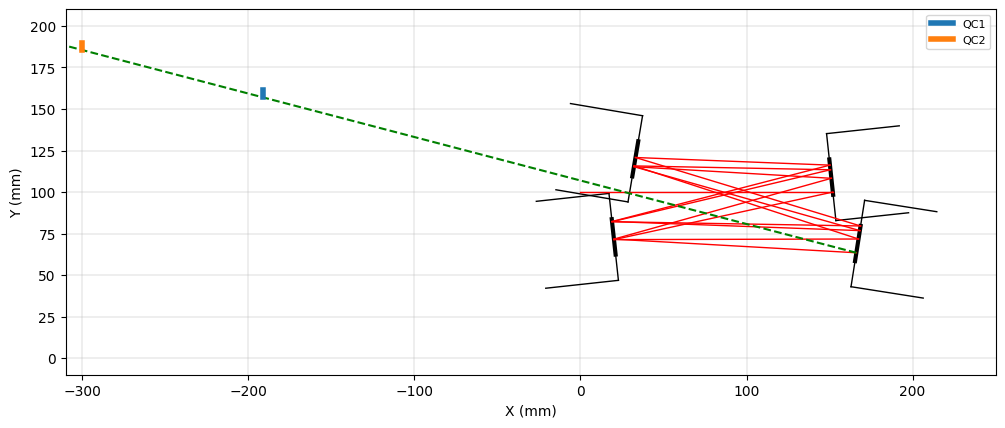

In [70]:
x3 = -1.00      # 0: N_r = 7, 0.00: N_r = 11, -1.0: N_r = 15
a3 = -0.65      # 0: N_r = 7, -.45: N_r = 11, -.65: N_r = 15
S.simulation(M1[0], M1[1],
             M2[0], M2[1],
             M3[0]+x3, M3[1],
             M4[0], M4[1],
             M1[2], M2[2], M3[2]+a3, M4[2])

NOT CLIPPED, room to spare: 3.2919465332418767 mm
Laser Path: [(0, 100), (np.float64(151.96677968156126), np.float64(100.0)), (np.float64(20.178626139208717), np.float64(71.35611928144868)), (np.float64(168.3967813695139), np.float64(71.71983742321856)), (np.float64(31.786430024701048), np.float64(112.81044510541987)), (np.float64(151.1328038325064), np.float64(107.76369506377401)), (np.float64(19.957604259408498), np.float64(73.39016428847344)), (np.float64(167.78154668637538), np.float64(67.50255696644659)), (np.float64(-801.1513601510302), np.float64(314.8262761031596))]
Total Laser Length: 1497.629602290314 mm
Total Number of Reflection (N_R) = 7


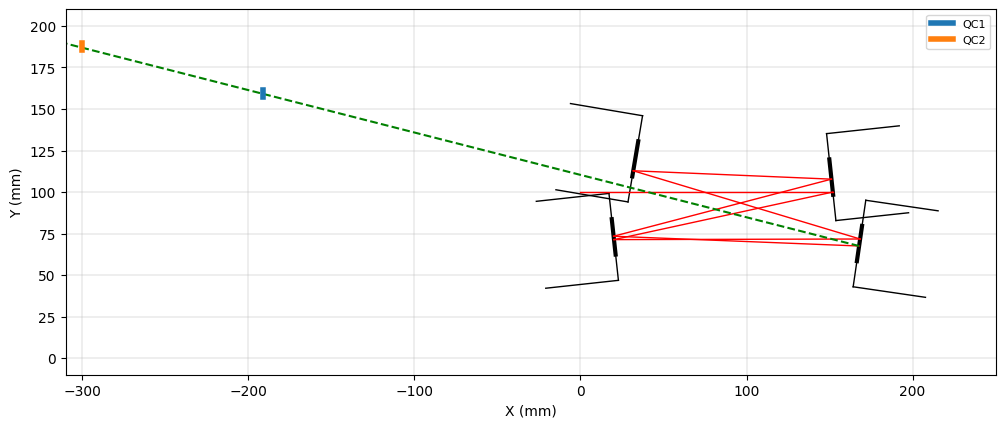

In [71]:
# Recenter current state
x_cur = S.pack_variables(M1, M2, M3, M4)
x_centered, _ = S.solve_recenter_angles(x_cur,
                        M1, M2, M3, M4,
                        15)

M1_c, M2_c, M3_c, M4_c = S.unpack_variables(x_centered, M1, M2, M3, M4)
S.simulation(M1_c[0], M1_c[1],
             M2_c[0], M2_c[1],
             M3_c[0], M3_c[1],
             M4_c[0], M4_c[1],
             M1_c[2], M2_c[2], M3_c[2], M4_c[2])

In [20]:
# Solving Inverse Problem importing images here:
res = S.optimize_inverse(M1, M2, M3, M4, img_path_light=r'C:\Users\rytoa\Desktop\School Stuff\Research\Delay Line\DelayLine-main\Inverse Simulation\Stage Movement Photos\06-17-L6.jpg', 
                        img_path_dark=r'C:\Users\rytoa\Desktop\School Stuff\Research\Delay Line\DelayLine-main\Inverse Simulation\Stage Movement Photos\06-17-D6.jpg',
                        qc1_disp=qc1_x, qc2_disp=qc2_x)

ValueError: operands could not be broadcast together with shapes (12,2) (11,2) 

In [ ]:
x = res.x

K1 = np.array([x[0], x[4], x[8]])
K2 = np.array([x[1], x[5], x[9]])
K3 = np.array([x[2], x[6], x[10]])
K4 = np.array([x[3], x[7], x[11]])
print(K1, K2, K3, K4)

[181.98742914 109.72234719  93.67520394] [17.79979716 74.44917476 92.91711119] [168.76718674  69.36197468  80.84612172] [ 40.19341535 117.66002991  80.29060775]


NOT CLIPPED, room to spare: 3.0490724320505187 mm
Laser Path: [(0, 100), (182.60826195436937, 100.0), (17.582498349509876, 78.72931173319992), (169.63567459098678, 74.62564196395783), (39.55288061384138, 113.96074704512549), (182.13389462176207, 107.39107524789966), (17.59764770754049, 78.4301863283873), (168.46619103742958, 67.39322868481963), (-801.0373640380743, 312.47047507044266)]
Total Laser Length: 1615.119689824562 mm
Total Number of Reflection (N_R) = 7


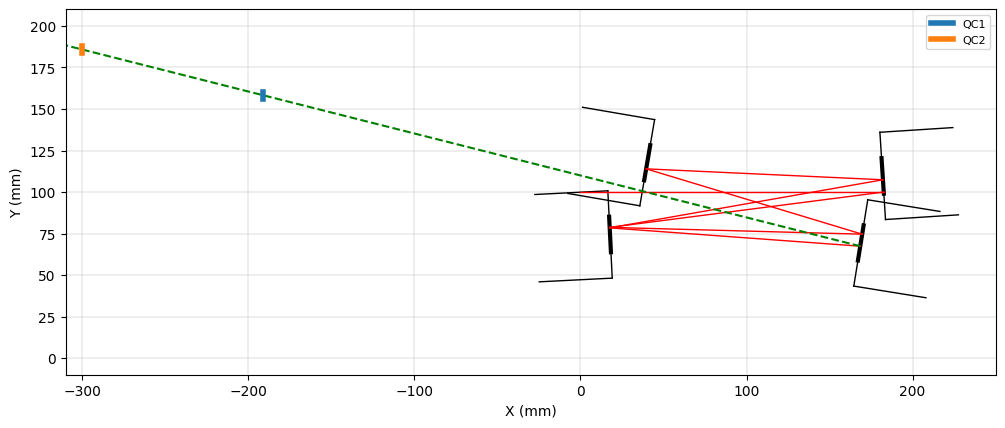

In [ ]:
#Fitted Model
S.simulation(K1[0], K1[1],
             K2[0], K2[1],
             K3[0], K3[1],
             K4[0], K4[1],
             K1[2], K2[2], K3[2], K4[2])

CLIPPED, -0.5010794709412671 mm too much
Laser Path: [(0, 100), (159.20768320556542, 100.0), (41.35427750889761, 69.86195896420257), (193.65433390172797, 68.41071732787013), (39.05198194480053, 109.9072630913792), (158.39045066569528, 106.4943382215114), (40.9904425950441, 72.86883816229022), (193.46879225708588, 67.05363055577091), (-779.3620722099608, 298.57060431860015)]
Total Laser Length: 1528.529533360106 mm
Total Number of Reflection (N_R) = 7


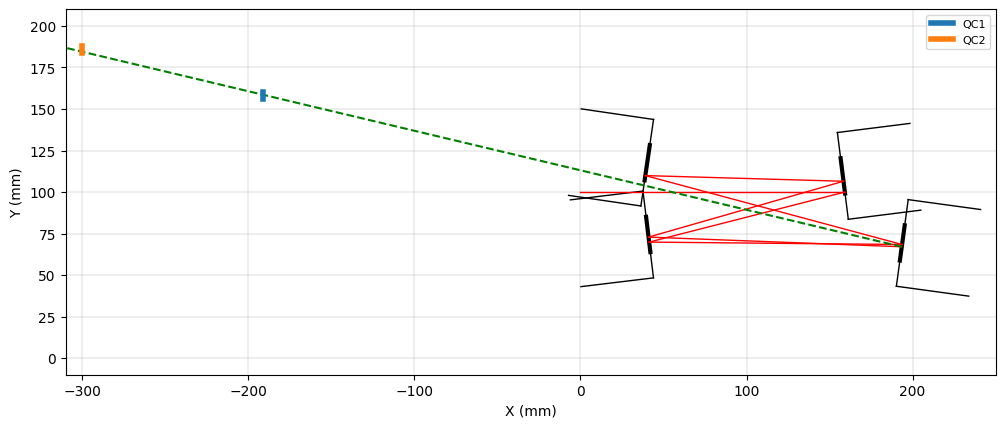

In [ ]:
#Fitted Model
S.simulation(K1[0]-24, K1[1],
             K2[0]+23, K2[1],
             K3[0]+25, K3[1],
             K4[0], K4[1],
             K1[2]+3.5, K2[2]+4, K3[2]+1.4, K4[2]+1.4)

In [ ]:
L1, L2, L3, L4 = Ms_opt[0], Ms_opt[1], Ms_opt[2], Ms_opt[3]

In [ ]:
Ms_opt, res = S.center_quadcells(
    L1, L2, L3, L4,
    N_R=35,
    n_tries=20000,
    angle_perturb=0.4,
    u_min=0.01,
    u_max=0.99,
)

Exit slope: -0.252376237725
Total length: 5408.162739335336
y191 error: -0.000000021904
y300 error: -0.000990109842
y595 error: 0.000000019135
Exit slope: -0.258207365871
Total length: 5408.425828720285
y191 error: -0.071362213112
y300 error: 0.563240666838
y595 error: 2.284413598814
Exit slope: -0.253379121961
Total length: 5408.233709307171
y191 error: -0.217443384895
y300 error: -0.109119091142
y595 error: 0.187721887365
Exit slope: -0.258872059449
Total length: 5408.741680090642
y191 error: 0.456576894337
y300 error: 1.163631374261
y595 error: 3.080888911667
Exit slope: -0.252376237624
Total length: 5408.253363532183
y191 error: -0.000000000023
y300 error: -0.000990099034
y595 error: -0.000000000028
Exit slope: -0.254534895447
Total length: 5408.184520363540
y191 error: -0.468098294810
y300 error: -0.233794691104
y595 error: 0.403999465715
Exit slope: -0.252376237623
Total length: 5408.122081427390
y191 error: 0.000000000090
y300 error: -0.000990098961
y595 error: -0.000000000064
E

NOT CLIPPED, room to spare: 3.0253540981923557 mm
Laser Path: [(0, 100), (159.31443754030144, 100.0), (41.72466476868101, 67.2092761753369), (193.06653760595574, 64.53404285672134), (38.88496287724067, 108.46355939628853), (158.21841115185137, 108.01080745927074), (40.757539009139904, 74.77521833872453), (194.09980578978804, 71.48262209242503), (39.78482534048601, 114.81783159279195), (157.40920163527238, 113.92528333305944), (40.059043755458234, 80.23963146040981), (194.82048384426855, 76.32907787548938), (40.386467653074675, 119.06625751927709), (156.8872516490038, 117.74019225079053), (39.629622961352936, 83.59904243659788), (195.2290365644544, 79.07653588551376), (40.690354683203765, 121.21211978745458), (156.65302553194547, 119.452140380379), (39.46974101485348, 84.84981830338756), (195.32590544257658, 79.72796509395916), (40.696928979744314, 121.25854340375747), (156.70700940812708, 119.05757466320895), (39.5798828430768, 83.98816541710434), (195.1115087640345, 78.28617840969693)

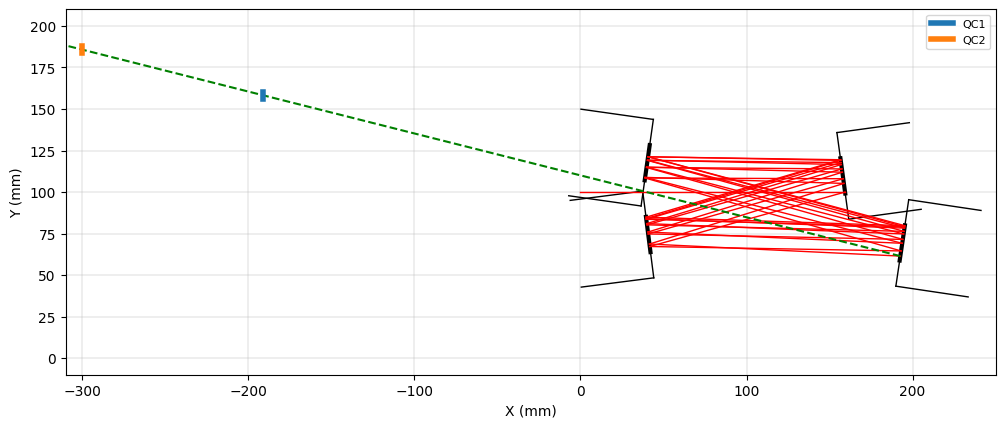

In [ ]:
S.simulation(Ms_opt[0][0], Ms_opt[0][1], 
             Ms_opt[1][0], Ms_opt[1][1], 
             Ms_opt[2][0], Ms_opt[2][1],
             Ms_opt[3][0], Ms_opt[3][1], 
             Ms_opt[0][2], Ms_opt[1][2], Ms_opt[2][2], Ms_opt[3][2])

In [ ]:
K1, K2, K3, K4

(array([181.98429764, 109.7219326 ,  93.67226934]),
 array([17.79930227, 74.44849928, 92.89929668]),
 array([168.78358263,  69.35606703,  80.81475883]),
 array([ 40.18747123, 117.66106783,  80.26866239]))

In [ ]:
Ms_opt

(array([181.98429764, 109.7219326 ,  93.9080422 ]),
 array([17.79930227, 74.44849928, 93.06238235]),
 array([168.78358263,  69.35606703,  81.06771449]),
 array([ 40.18747123, 117.66106783,  81.41113934]))

In [ ]:
S.simulation_identifier(K1[0], K1[1], 
             K2[0], K2[1], 
             K3[0], K3[1],
             K4[0], K4[1], 
             K1[2], K2[2], K3[2], K4[2]) #y191 is qc1, y595 is qc2

Exit slope: -0.087879488130
Total length: 0.000000000000
y191 error: -70.568311820674
y300 error: -88.499447614548
y595 error: -137.024998616317


(-0.0878794881295948,
 0,
 -70.56831182067366,
 -88.49944761454782,
 -137.02499861631733)

In [ ]:
Ms_opt, res = S.center_quadcells(
    K1, K2, K3, K4,
    N_R=11,
    n_tries=2000,
    angle_perturb=0.3,
    u_min=0.1,
    u_max=0.9,
)

Exit slope: -0.252376237446
Total length: 2212.479443454542
y191 error: 0.000000041658
y300 error: -0.000990076778
y595 error: -0.000000030342
Exit slope: -0.252376237535
Total length: 2212.528761053464
y191 error: 0.000000020632
y300 error: -0.000990088004
y595 error: -0.000000015048
Exit slope: -0.252376237800
Total length: 2212.552698630807
y191 error: -0.000000041098
y300 error: -0.000990120940
y595 error: 0.000000029944
Exit slope: -0.252376237644
Total length: 2212.397008655663
y191 error: -0.000000004610
y300 error: -0.000990101460
y595 error: 0.000000003393
Exit slope: -0.252376237644
Total length: 2212.771542799283
y191 error: -0.000000004678
y300 error: -0.000990101501
y595 error: 0.000000003428
Exit slope: -0.252376237594
Total length: 2212.532101984891
y191 error: 0.000000006934
y300 error: -0.000990095310
y595 error: -0.000000005052
Exit slope: -0.252376237548
Total length: 2212.527507187363
y191 error: 0.000000017660
y300 error: -0.000990089582
y595 error: -0.000000012852

NOT CLIPPED, room to spare: 3.0090169725358393 mm
Laser Path: [(0, 100), (182.6484434616866, 100.0), (17.644072005241014, 77.35002072259435), (169.33602170089313, 72.87091019272879), (39.126192758876726, 110.63445171828835), (182.0931997544351, 108.12779615976956), (17.365018514936708, 82.5660118593428), (169.73223445818772, 75.39177769171177), (39.15024920295318, 110.79372697219897), (182.2539920768647, 105.77407795694057), (17.648474806151512, 77.26772477818227), (168.49379331821058, 67.51230899290239), (-801.1041668358597, 312.2157941848095)]
Total Laser Length: 2212.477969169910 mm
Total Number of Reflection (N_R) = 11


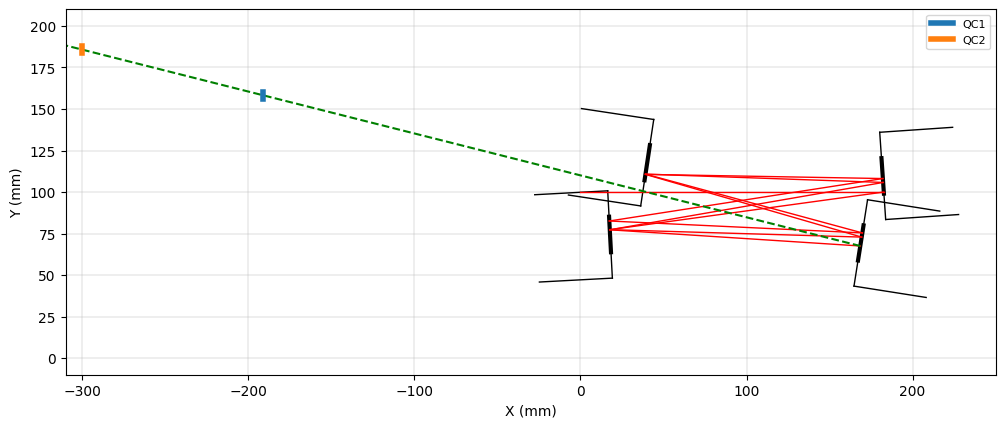

In [ ]:
S.simulation(Ms_opt[0][0], Ms_opt[0][1], 
             Ms_opt[1][0], Ms_opt[1][1], 
             Ms_opt[2][0], Ms_opt[2][1],
             Ms_opt[3][0], Ms_opt[3][1], 
             Ms_opt[0][2], Ms_opt[1][2], Ms_opt[2][2], Ms_opt[3][2])

In [ ]:
M1o, M2o, M3o, M4o = Ms_opt
x_opt = S.pack_variables(M1o, M2o, M3o, M4o)

u = S.reflection_us_from_variables(
    x_opt, M1o, M2o, M3o, M4o,
    include_ends=False,
)

print("u values:", u)
print("closest edge distance:", min(min(ui, 1 - ui) for ui in u))
print("closest center distance:", max(abs(ui - 0.5) for ui in u))

u values: [0.37407094 0.71665472 0.2594364  0.49483035 0.66144915 0.85689095
 0.26685748 0.36269919 0.36564093]
closest edge distance: 0.1431090461604536
closest center distance: 0.3568909538395464


In [ ]:
mirrors, res, execution = A.execute_reflection_count_fixed_plan(
    11, K1, K2, K3, K4,
    hardware=H,
    dry_run=True,
    profile=True,
    qc_reacquire_limit=2.0,
    final_qc_tolerance=0.5,
    final_center_after_reacquire=False,
    require_target_N_R_estimate_for_reacquire_stop=False,
    require_beam_departure_before_reacquire=True,
    min_reacquire_pulse_fraction=0.0,
    u_min=0.1,
    u_max=0.9,
    max_total_steps=500,
    rotation_settle_delay=0.5,
    calibrate_before=True,
    calibration_pulse_substeps=5,
    calibration_repeats=3,
)

[calibrate_rotation 3.043s] M1.dangle +5 substeps: mean=0.0110859 deg std=0.000747
[calibrate_rotation 6.083s] M1.dangle -5 substeps: mean=-0.0110599 deg std=0.000414
[calibrate_rotation 9.640s] M2.dangle +5 substeps: mean=0.0118209 deg std=0.00109
[calibrate_rotation 12.690s] M2.dangle -5 substeps: mean=-0.0120002 deg std=0.000697
[calibrate_rotation 16.245s] M3.dangle +5 substeps: mean=0.0119844 deg std=0.000497
[calibrate_rotation 19.300s] M3.dangle -5 substeps: mean=-0.0117997 deg std=0.00107
[calibrate_rotation 22.856s] M4.dangle +5 substeps: mean=0.0116833 deg std=0.000862
[calibrate_rotation 25.901s] M4.dangle -5 substeps: mean=-0.0115647 deg std=5.25e-05
[calibrate_rotation 26.405s] done success=True failure=None
[execute_N_R 26.406s] calibration complete; planning from post-calibration mirror estimate
[execute_N_R 29.237s] start target_N_R=11 dry_run=True planned_steps=0 search_mode=failed qc_reacquire_limit=3.0 failure=Planner failed: No one- or two-actuator reacquisition pla

NOT CLIPPED, room to spare: 3.239713811957511 mm
Laser Path: [(0, 100), (182.60882198938128, 100.0), (17.583479412731293, 78.71011653836506), (169.62948484557643, 74.58854732271102), (39.542276647477564, 113.8979762803025), (182.13909150473518, 107.31226585649809), (17.603547143750035, 78.31386106346872), (168.44226812069712, 67.24480475316003), (-801.1341287115245, 312.03371525738703)]
Total Laser Length: 1614.947043101185 mm
Total Number of Reflection (N_R) = 7


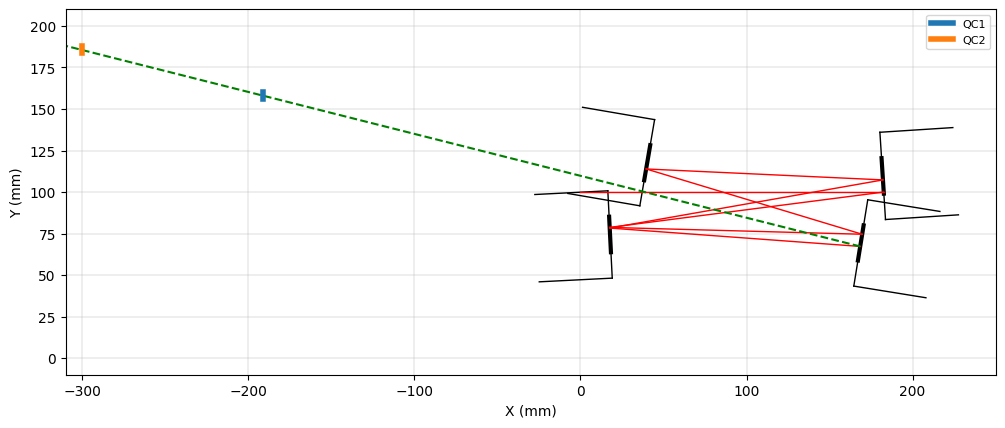

In [ ]:
S.simulation(mirrors[0][0], mirrors[0][1], 
             mirrors[1][0], mirrors[1][1], 
             mirrors[2][0], mirrors[2][1],
             mirrors[3][0], mirrors[3][1], 
             mirrors[0][2], mirrors[1][2], mirrors[2][2], mirrors[3][2])

In [ ]:
qc = H.quads.get_xy_position()
qc1_x = qc[0]
qc2_x = qc[2]
qc1_x, qc2_x

(-0.16134699981252915, -0.11551824621193196)

In [ ]:
# Solves for path to mirror configuration that corresponds to a desired OPD
mirrors_opt, res, actuation_plan = S.choose_OPD(
    2170, K1, K2, K3, K4,
    M1_linear_loc=24,
    M2_linear_loc=24,
    M3_linear_loc=0,
    qc_plan_limit=0.5,
    qc_detector_limit=3.9,
    qc_hardware_stop=3.5,
    final_qc_tolerance=0.25,
    u_min=0.06,
    u_max=0.94,
    max_axis_splits = 80,
    profile=True,
)

[choose_OPD 0.001s] start OPD=2173.667 target=2170.000 qc=(-0.023,-0.016) u=[0.255,0.999] ok=False
[choose_OPD 0.028s] initial recenter solve least_squares dt=0.026s success=True
[choose_OPD 0.029s] initial recenter solve least_squares accepted
[choose_OPD 0.029s] initial recenter solve dt=0.027s qc=(-0.000,0.000) u=[0.110,0.792]
[choose_OPD 0.030s] initial recenter path using recovery_qc_limit=0.500 endpoint_max_qc=0.023 u=[0.0500,0.9999]
[choose_OPD 53.201s] initial recenter path fast path proposal dt=53.171s samples=5 steps=214 failure=None
[choose_OPD 56.762s] initial recenter path fast path dense validation dt=3.561s samples=25 ok=True reason=None
[choose_OPD 56.763s] initial recenter path dt=56.734s steps_added=214 failure=None
[choose_OPD 56.763s] iteration=1 OPD=2173.345 target=2170.000 steps=214
[choose_OPD 56.763s] stage=M3 skipped dx_limit=-0
[choose_OPD 56.764s] iteration=2 OPD=2173.345 target=2170.000 steps=214
[choose_OPD 56.796s] linear search stage=M2 valid_fraction=0.0

In [ ]:
mirrors, res, execution = A.execute_OPD_fixed_plan(
    2170, K1, K2, K3, K4,
    hardware=H,
    M1_linear_loc=24,
    M2_linear_loc=24,
    M3_linear_loc=0,
    dry_run=False,
    profile=True,
    qc_plan_limit=0.5,
    qc_detector_limit=3.9,
    qc_hardware_stop=3.5,
    final_qc_tolerance=0.25,
    qc_step_tolerance=0.10,
    max_rotation_chunk_substeps=50,
    max_rotation_chunks_per_step=100,
    rotation_settle_delay=0.5,
    linear_settle_delay=2.0,
    max_total_steps=500,
    choose_OPD_kwargs={
        "u_min": 0.06,
        "u_max": 0.94,
        "max_axis_splits": 80,
    },
)

[execute_fixed_OPD 100.639s] start target_OPD=2170.000 dry_run=False planned_steps=390 failure=None ignored_planner_failure=False
[execute_fixed_OPD 103.373s] step=1/390 actuator=M4.dangle miss=0.178 qc_x=(-0.266,-0.137)
[execute_fixed_OPD 107.657s] step=2/390 actuator=M3.dangle miss=0.057 qc_x=(0.300,0.502)
[execute_fixed_OPD 116.768s] step=3/390 actuator=M4.dangle miss=0.175 qc_x=(-0.279,-0.125)
[execute_fixed_OPD 121.051s] step=4/390 actuator=M3.dangle miss=0.055 qc_x=(0.284,0.505)
[execute_fixed_OPD 130.160s] step=5/390 actuator=M4.dangle miss=0.179 qc_x=(-0.298,-0.124)
[execute_fixed_OPD 134.443s] step=6/390 actuator=M3.dangle miss=0.051 qc_x=(0.272,0.509)
[execute_fixed_OPD 143.558s] step=7/390 actuator=M4.dangle miss=0.167 qc_x=(-0.300,-0.100)
[execute_fixed_OPD 147.846s] step=8/390 actuator=M3.dangle miss=0.058 qc_x=(0.247,0.508)
[execute_fixed_OPD 156.962s] step=9/390 actuator=M4.dangle miss=0.170 qc_x=(-0.316,-0.088)
[execute_fixed_OPD 161.255s] step=10/390 actuator=M3.dangle

ValueError: Signal too low for 69253622: 0.03936827649347677

In [ ]:
print("failure_reason:", execution["failure_reason"])
print("execution_log length:", len(execution["execution_log"]))

for s in execution["actuation_plan"]["steps"][:10]:
    print(
        s["step"],
        s.get("actuator"),
        s.get("axis_index"),
        s.get("command_value"),
        s.get("single_actuator_step"),
        "OPD=", s.get("OPD"),
        "qc=", (s.get("qc1_error"), s.get("qc2_error")),
    )

failure_reason: Hardware execution failed for M1.dx: Cannot move to requested position
   at Thorlabs.MotionControl.GenericMotorCLI.AdvancedMotor.GenericAdvancedMotorCLI.VerifyDeviceMovement(Int32 functionDepth, Decimal position, PositionType positionType)
   at Thorlabs.MotionControl.GenericMotorCLI.AdvancedMotor.GenericAdvancedMotorCLI.MoveRelative(MotorDirection direction, Decimal stepSize, Int32 waitTimeout)
execution_log length: 0
1 M1.dx 0 -1.0 True OPD= 1524.2789131371856 qc= (0.4383455228000628, 0.4516134463949584)
2 M2.dx 2 -1.969598070933209 True OPD= 1531.4999482317423 qc= (-0.4999999999997726, -0.4867320764048486)
3 M1.dangle 1 -0.01020116824540196 True OPD= 1531.934116264625 qc= (0.18062725815786962, 0.49999999998868816)
4 M3.dangle 5 0.013025322692570285 True OPD= 1531.5331606884042 qc= (-0.4285434375143211, -0.49999999997834266)
5 M1.dangle 1 -0.010338873632505852 True OPD= 1531.9730442428634 qc= (0.2612497974029111, 0.4999999999594138)
6 M3.dangle 5 0.013025944585834281

In [ ]:
print("success:", execution["success"])
print("failure_reason:", execution["failure_reason"])
print("final_OPD:", execution["final_OPD"])
print("final_OPD_error:", execution["final_OPD_error"])
print("final_qc_y:", execution["final_qc_y"])
print("max_abs_measured_qc:", execution["max_abs_measured_qc"])
print("max_step_target_miss:", execution["max_step_target_miss"])
print("needs_final_recenter:", execution["needs_final_recenter"])

success: False
failure_reason: Fixed-plan final checks failed: final_OPD_within_tolerance
final_OPD: 0.0
final_OPD_error: -1502.0
final_qc_y: [0.3782292671106745, 0.17727543232243087]
max_abs_measured_qc: 0.7393880528767327
max_step_target_miss: 0.27771296343453233
needs_final_recenter: True


In [ ]:
execution

{'success': False,
 'failure_reason': 'Fixed-plan final checks failed: final_OPD_within_tolerance',
 'success_checks': {'no_failure_reason': True,
  'final_OPD_within_tolerance': False,
  'final_qc_required': False,
  'final_qc_within_tolerance': False,
  'needs_final_recenter': True,
  'final_OPD_error': 2.9215036936125216,
  'final_OPD_tolerance': 0.5,
  'final_qc_max_abs': 0.5058216718323384,
  'final_qc_tolerance': 0.5,
  'planner_failure_ignored': False,
  'planner_failure_reason': None},
 'fixed_plan': True,
 'planner_failure_ignored': False,
 'planner_failure_reason': None,
 'needs_final_recenter': True,
 'target_OPD': 1460.0,
 'final_OPD': 1462.9215036936125,
 'final_OPD_error': 2.9215036936125216,
 'final_sim_qc': [4.06433119729752, 6.876843929001495],
 'final_qc_x': [0.5058216718323384, -0.4903450118764845],
 'final_qc_y': [0.5058216718323384, -0.4903450118764845],
 'max_abs_measured_qc': 1.3554930876147009,
 'max_step_target_miss': 0.65949369657855,
 'max_abs_OPD_divergence'

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Reflection Positions During Fixed-Plan Execution'}, xlabel='Actuator step', ylabel='Reflection position u'>)

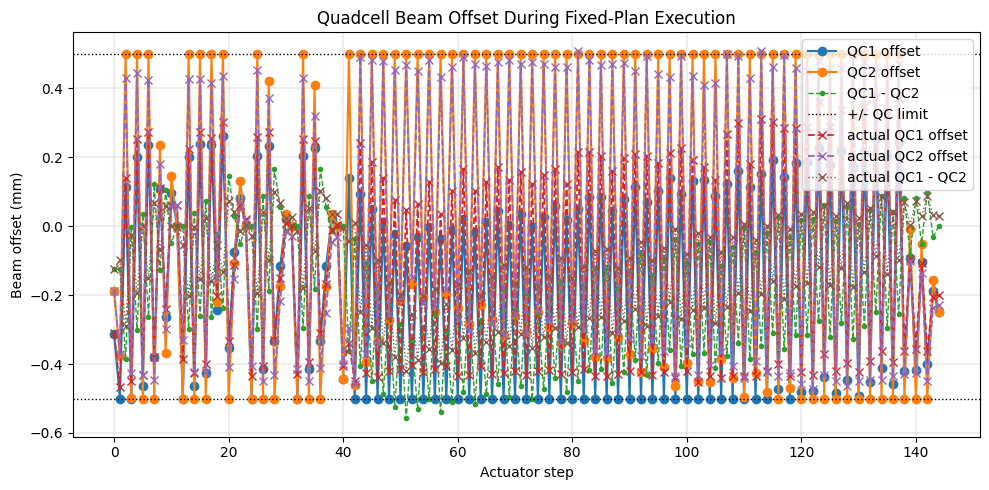

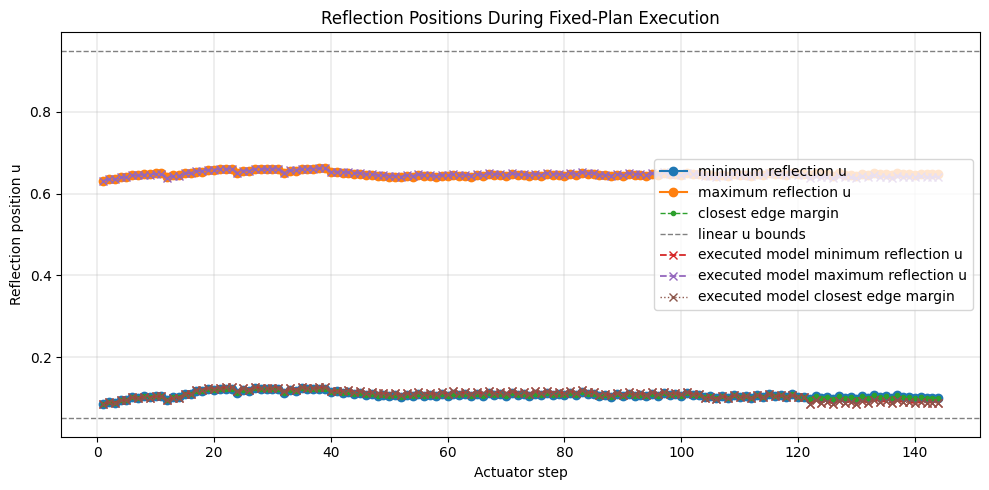

In [ ]:
A.plot_fixed_plan_quadcell_overlay(execution)
A.plot_fixed_plan_reflection_u_overlay(execution)

NOT CLIPPED, room to spare: 3.239713811957511 mm
Laser Path: [(0, 100), (182.60882198938128, 100.0), (17.583479412731293, 78.71011653836506), (169.62948484557643, 74.58854732271102), (39.542276647477564, 113.8979762803025), (182.13909150473518, 107.31226585649809), (17.603547143750035, 78.31386106346872), (168.44226812069712, 67.24480475316003), (-801.1341287115245, 312.03371525738703)]
Total Laser Length: 1614.947043101185 mm
Total Number of Reflection (N_R) = 7


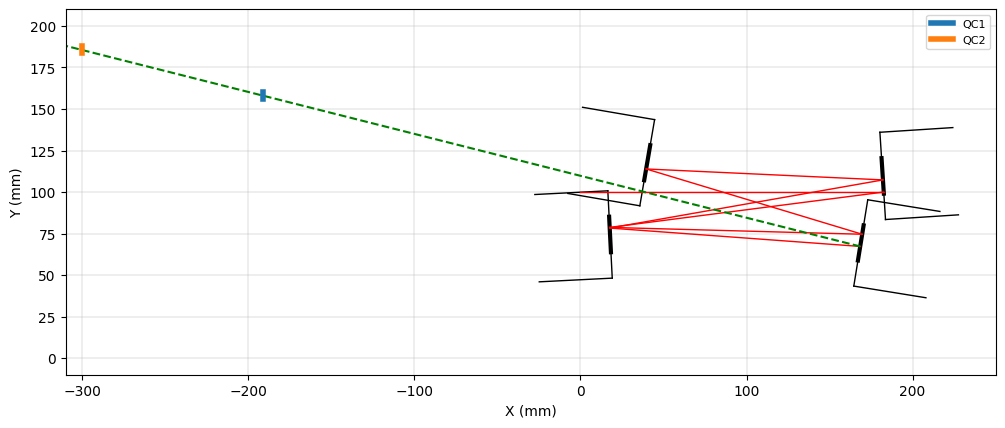

In [ ]:
S.simulation(mirrors[0][0], mirrors[0][1], 
             mirrors[1][0], mirrors[1][1], 
             mirrors[2][0], mirrors[2][1],
             mirrors[3][0], mirrors[3][1], 
             mirrors[0][2], mirrors[1][2], mirrors[2][2], mirrors[3][2])

In [ ]:
(1504.560992489732 - 1502.244821266105) / 3636.0953303 # 6-12-6 ### 24 steps

print(3636.0953303 * 0.000000635)
print(1504.560992489732 - 1502.244821266105)

0.0023089205347405
2.3161712236269523


In [ ]:
(1434.982605543342 - 1426.601802534593) / 13266.5466494 # 6-12-8 ### 13 steps

print(13266.5466494 * 0.000000635)
print(1434.982605543342 - 1426.601802534593)

0.008424257122369
8.380803008749126


In [ ]:
(1445.041787792887 - 1435.284093967351) / 15410.3440648 # 6-12-10 ### 37 steps
print(15410.3440648 * 0.000000635)
print(1445.041787792887 - 1435.284093967351)

0.009785568481148
9.757693825535853


In [ ]:
(1454.957524961510 - 1448.897870847571) / 9613.15383088 # 

print(9613.15383088 * 0.000000635)
print(1454.957524961510 - 1448.897870847571)
print((1454.957524961510 - 1448.897870847571)- 1000*(9613.15383088 * 0.000000635))

0.0061043526826088
6.059654113938905
-0.04469856866989552


In [ ]:
(1469.974845193061 - 1454.971516114675) / 23436.392451087

print(23436.392451087 * 0.000000635)
print(1469.974845193061 - 1454.971516114675)
print((1469.974845193061 - 1454.971516114675)- 1000*(23436.392451087 * 0.000000635))

0.014882109206440243
15.003329078385832
0.12121987194558947


In [ ]:
(1469.895526147592 - 1462.956250368271) / 10997.59943554 ## 1463 - 1470

print(10997.59943554 * 0.000000635)
print(1469.895526147592 - 1462.956250368271)
print((1469.895526147592 - 1462.956250368271) - 1000 * (10997.59943554 * 0.000000635))

0.0069834756415679
6.939275779320951
-0.044199862246948385


In [ ]:
(1479.920674229659 - 1469.710167777279) / 16313.783000 # 1470 - 1480

print(16313.783000 * 0.000000635)
print(1479.920674229659 - 1469.710167777279)
print((1479.920674229659 - 1469.710167777279) - 1000 * (16313.783000 * 0.000000635))

0.010359252204999999
10.21050645238006
-0.1487457526199396


In [ ]:
(1489.918113315543 - 1479.803591390292) / 15859.56292485 # 1480 - 1490

print((1489.918113315543 - 1479.803591390292) - 1000 * (15859.56292485 * 0.000000635))

0.043699467971233474


In [ ]:
(1499.930872797509 - 1490.247865037984) / 15564.14248546

print((1499.930872797509 - 1490.247865037984) - 1000 * (15564.14248546) * 0.000000635)

-0.20022271874207398


In [ ]:
(1509.976880340761 - 1500.407909486046) / 15246.96442138 # 1500 - 1510

print((1509.976880340761 - 1500.407909486046) - 1000 * (15564.14248546) * 0.000000635)

-0.31425962355213777


In [ ]:
(1519.775831928075 - 1509.794942656980) / 15706.14817077
print((1519.775831928075 - 1509.794942656980) - 1000 * 15706.14817077 * 0.000000635)

0.0074851826558894885


In [ ]:
(1527.991320894919 - 1519.421598688910) / 13485.43210394
print((1527.991320894919 - 1519.421598688910) - 1000 * 13485.43210394 * 0.000000635)

0.006472820007019209


In [ ]:
(1539.913888916383 - 1527.813042383840) / 19536.488335
print((1539.913888916383 - 1527.813042383840) - 1000 * 19536.488335 * 0.000000635)

-0.3048235601819247


In [ ]:
(1549.971030348309 - 1539.623070782534) / 16143.13670186
print((1549.971030348309 - 1539.623070782534)-1000*16143.13670186*0.000000635)

0.09706776009389984


In [ ]:
(1559.983160585952 - 1550.146802180416) / 15627.5090847
print((1559.983160585952 - 1550.146802180416)-1000*15627.5090847*0.000000635)

-0.08710986324852321


In [ ]:
(1569.906958743393 - 1560.225387297758) / 15543.30151895
print((1569.906958743393 - 1560.225387297758) - 1000*15543.30151895*0.000000635)

-0.18842501889827723


In [ ]:
(1579.962814864610 - 1569.861202994335) / 16126.489607
print((1579.962814864610 - 1569.861202994335) - 1000 * 16126.489607 * 0.000000635)

-0.13870903016993452


In [ ]:
(1599.944020399811 - 1579.840960581595) / 31909.38285
print((1599.944020399811 - 1579.840960581595) - 1000 * 31909.38285 * 0.000000635)

-0.1593982915339751


In [ ]:
(1620.002910300206 - 1599.904143600581) / 31577.901972
print((1620.002910300206 - 1599.904143600581) - 1000 * 31577.901972 * 0.000000635)

0.04679894740500501


In [ ]:
import pickle

save_data = {
    "K1": K1,
    "K2": K2,
    "K3": K3,
    "K4": K4,
    "mirrors": mirrors,
    "res": res,
    "execution": execution,
}

filename = "6-13-24.pkl"

with open(filename, "wb") as f:
    pickle.dump(save_data, f)

print("saved:", filename)

saved: 6-13-24.pkl


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Reflection Positions During Fixed-Plan Execution'}, xlabel='Actuator step', ylabel='Reflection position u'>)

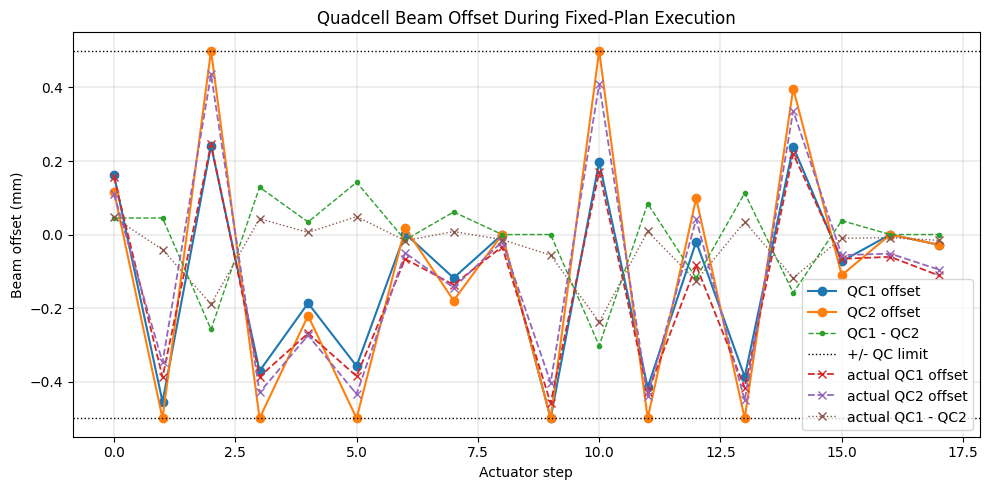

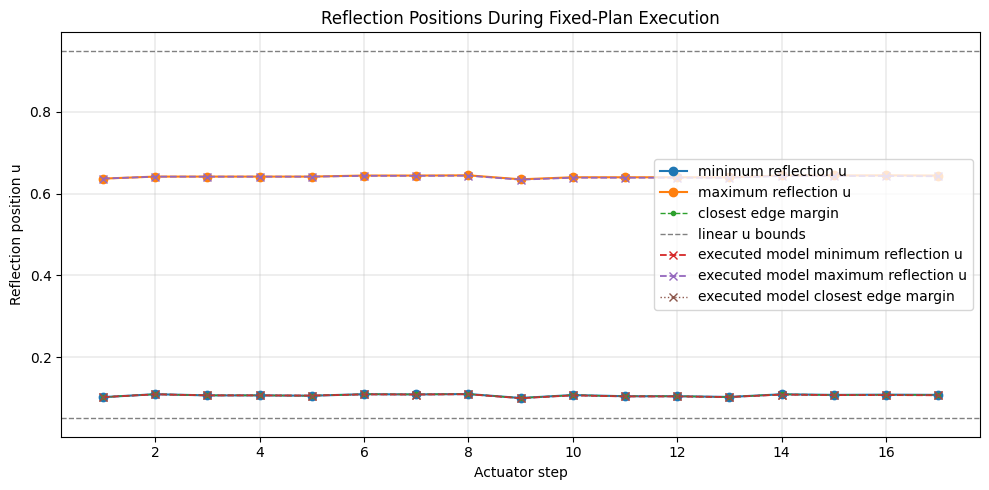

In [ ]:
import pickle
import alignment_ops as A

with open("6-13-22.pkl", "rb") as f:
    data = pickle.load(f)

execution = data["execution"]

A.plot_fixed_plan_quadcell_overlay(execution)
A.plot_fixed_plan_reflection_u_overlay(execution)

Mean signed error: 78.5 um
Mean absolute error: 116.5 um
RMS error: 148.4 um
Max absolute error: 314.3 um


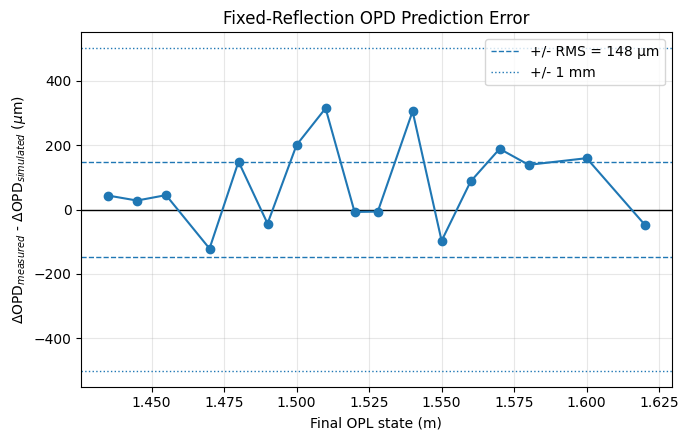

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Final OPD/OPL value for each move, in mm.
# Example: 1426 -> 1435 means final_opd_mm = 1435.
final_opd_mm = np.array([
    1435, 1445, 1455, 1470,
    1480, 1490, 1500, 1510, 1520,
    1528, 1540, 1550, 1560, 1570,
    1580, 1600, 1620
], dtype=float)

# Your notebook column appears to be:
# OPD_simulated - OPD_measured, in microns.
sim_minus_meas_um = np.array([
    -43.45, -27.87, -44.70, 121.22,
    -148.75, 43.70, -200.22, -314.26, 7.49,
    6.47, -304.82, 97.07, -87.11, -188.43,
    -138.71, -159.40, 46.80
], dtype=float)

# Convert to requested sign:
# OPD_measured - OPD_simulated
meas_minus_sim_um = -sim_minus_meas_um

# Summary statistics
rms_error_um = np.sqrt(np.mean(meas_minus_sim_um**2))
mean_error_um = np.mean(meas_minus_sim_um)
mean_abs_error_um = np.mean(np.abs(meas_minus_sim_um))
max_abs_error_um = np.max(np.abs(meas_minus_sim_um))

print(f"Mean signed error: {mean_error_um:.1f} um")
print(f"Mean absolute error: {mean_abs_error_um:.1f} um")
print(f"RMS error: {rms_error_um:.1f} um")
print(f"Max absolute error: {max_abs_error_um:.1f} um")

# Plot residual vs final OPD
plt.figure(figsize=(7, 4.5))

plt.axhline(0, color='black', linewidth=1)
plt.axhline(rms_error_um, linestyle='--', linewidth=1, label=f'+/- RMS = {rms_error_um:.0f} µm')
plt.axhline(-rms_error_um, linestyle='--', linewidth=1)

# Optional: sub-mm bound
plt.axhline(500, linestyle=':', linewidth=1, label='+/- 1 mm')
plt.axhline(-500, linestyle=':', linewidth=1)

plt.plot(final_opd_mm / 1000, meas_minus_sim_um, 'o-', linewidth=1.5)

plt.xlabel('Final OPL state (m)')
plt.ylabel(r'$\Delta$OPD$_{measured}$ - $\Delta$OPD$_{simulated}$ ($\mu$m)')
plt.title('Fixed-Reflection OPD Prediction Error')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
S.simulation_identifier(mirrors[0][0], mirrors[0][1], 
             mirrors[1][0], mirrors[1][1], 
             mirrors[2][0], mirrors[2][1],
             mirrors[3][0], mirrors[3][1], 
             mirrors[0][2], mirrors[1][2], mirrors[2][2], mirrors[3][2])

Exit slope: -0.251894059304
Total length: 1445.061414869624
y191 error: 0.009482772475
y300 error: -0.044064763442
y595 error: -0.185317268906


(-0.2518940593035122,
 1445.0614148696243,
 0.009482772475223555,
 -0.04406476344195198,
 -0.18531726890586242)

In [ ]:
qc = H.quads.get_xy_position()
qc1_x = qc[0]
qc2_x = qc[2]
qc1_x, qc2_x

(0.45954458445521196, -0.12275367166211487)

NOT CLIPPED, room to spare: 3.005156430590329 mm
Laser Path: [(0, 100), (175.55170427752705, 100.0), (40.7808258432255, 67.47829956531208), (170.54138416196344, 76.03859417313471), (40.30884334417371, 118.77285501924513), (174.42799890105226, 109.44699889007414), (40.82212014908595, 67.20750873982749), (169.36877691414188, 66.75143703962571), (-800.1235379799318, 311.8731442818246)]
Total Laser Length: 1502.244821266105 mm
Total Number of Reflection (N_R) = 7


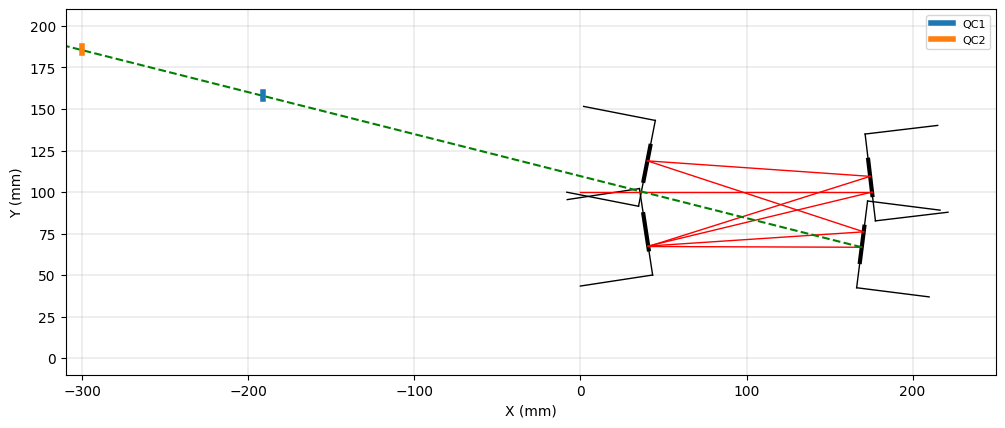

In [ ]:
#Fitted Model
S.simulation(K1[0], K1[1],
             K2[0], K2[1],
             K3[0], K3[1],
             K4[0], K4[1],
             K1[2], K2[2], K3[2], K4[2])

In [ ]:
import importlib
A = importlib.reload(A)

qc = H.quads.get_xy_position()
qc1_x, qc2_x = qc[0], qc[2]

print("raw qc:", qc)
print("hardware qc x:", qc1_x, qc2_x)
print("sim qc if sign=-1:", -qc1_x, -qc2_x)
print("sim qc if sign=+1:", qc1_x, qc2_x)

print("model qc:", S.quadcell_errors_from_mirrors(K1, K2, K3, K4))

raw qc: [2.6102726283723303, 0.45004700489178107, 3.572655801950523, 0.5261102722050427]
hardware qc x: 2.6102726283723303 3.572655801950523
sim qc if sign=-1: -2.6102726283723303 -3.572655801950523
sim qc if sign=+1: 2.6102726283723303 3.572655801950523


AttributeError: module 'Simulation' has no attribute 'quadcell_errors_from_mirrors'

In [ ]:
for s in execution["actuation_plan"]["steps"][:5]:
    print(
        s["step"],
        s["actuator"],
        "cmd=", s["command_value"],
        "OPD=", s["OPD"],
        "qc=", (s["qc1_error"], s["qc2_error"])
    )

1 M1.dx cmd= 1.4242972547661736 OPD= 1450.0 qc= (-0.4807247182268384, -1.4765858326259718)
2 M2.dangle cmd= 0.052903410129673034 OPD= 1451.8647833314953 qc= (2.4090829627650123, 2.9999999993549977)
3 M1.dangle cmd= 0.06403892536219757 OPD= 1449.2604794873323 qc= (-1.6705162092011108, -2.9999999988469312)
4 M2.dangle cmd= 0.07092062887913642 OPD= 1451.755975660241 qc= (2.2024562351542727, 2.999999999244494)
5 M1.dangle cmd= 0.06403117676710224 OPD= 1449.1499318682568 qc= (-1.8769105598170484, -2.999999999629381)


In [ ]:
for e in execution["execution_log"]:
    print("\nstep", e["execution_step"], e["actuator"])
    print("command:", e["command_value"])
    print("planned_qc_y:", e["planned_qc_y"])
    print("before_qc_y:", e["before_qc_y"])
    print("after_qc_y:", e["after_qc_y"])
    print("miss:", e["qc_target_miss"])
    print("detail:", e["detail"])


step 1 M1.dx
command: 1.796800104092
planned_qc_y: [1.7399927463738436, 0.12070297178945566]
before_qc_y: [0.7115077407648872, -0.921722284996067]
after_qc_y: [3.0834649078014036, 2.9659134597034025]
miss: 3.1464488187584365
detail: {'kind': 'linear', 'serial': '27266900', 'planned_sim_delta': 1.796800104092, 'hardware_delta': 1.796800104092, 'actual_sim_delta': 1.79679, 'before_position': 0.95147, 'after_position': 2.74826}

step 2 M2.dangle
command: 0.036873697620350754
planned_qc_y: [-0.2716081998662503, -2.999999998075282]
before_qc_y: [3.0834649078014036, 2.9659134597034025]
after_qc_y: [-0.14952457979651163, -3.0052760487640446]
miss: 0.1221975736264951
detail: {'kind': 'rotation_fixed_plan', 'controller': 'newport', 'actuator': 3, 'planned_angle_delta': 0.036873697620350754, 'degrees_per_substep': 0.0023, 'target_qc_x': [-0.2716081998662503, -2.999999998075282], 'target_qc_y': [-0.2716081998662503, -2.999999998075282], 'start_qc_x': [3.0834649078014036, 2.9659134597034025], 'st

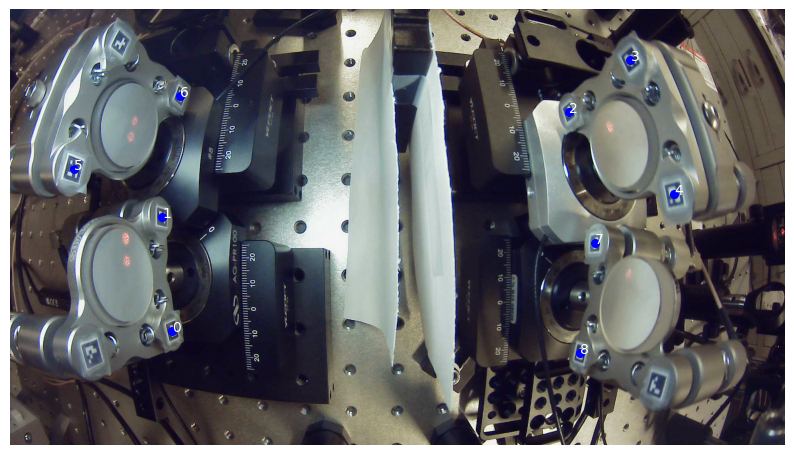

In [13]:
# Get aruco center points
image_path = "C:\\Users\\rytoa\\Desktop\\School Stuff\\Research\\Delay Line\\DelayLine-main\\Inverse Simulation\\Stage Movement Photos\\6-08-"
aruco_centers = S.camera_arucos(image_path+"L4.jpg")

img_bgr = cv.imread(image_path+"L4.jpg")
if img_bgr is None:
    raise FileNotFoundError("Could not read image path")

img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Plot center points on original image
plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.axis("off")

count = 0
for x, y in aruco_centers:
    plt.scatter(x, y, color='blue', s=30)
    plt.text(x, y, str(count), color='white')
    count += 1
plt.show()

In [16]:
# ---- Load images ----
img_light = cv.imread(image_path + "L4.jpg")
img_dark  = cv.imread(image_path + "D4.jpg")
gray = cv.cvtColor(img_dark, cv.COLOR_BGR2GRAY)

# ---- Measured points ----
aruco_centers_12 = S.camera_arucos(image_path + "L4.jpg")                 # list of 12
aruco_meas = S.group_aruco_centers_by_mirror(aruco_centers_12)

refl_meas = S.reflec_pts_cam(gray, show=False)                     # dict M1..M4

# ---- Determine corresponding simulation parameters ----
M1 = [151, 109, 96.1312] #x,y,a
M2 = [20, 73, 96.2015]
M3 = [168, 69, 81.7]
M4 = [33, 120, 80.419]

res = S.optimize_inverse(M1, M2, M3, M4, img_path_light=image_path + "L4.jpg", 
                        img_path_dark=image_path + "D4.jpg",
                        qc1_disp=None, qc2_disp=None)

# ---- Sim points (from solved theta) ----
M1x, M2x, M3x, M4x, M1y, M2y, M3y, M4y, M1a, M2a, M3a, M4a = x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7], x[8], x[9], x[10], x[11]

aruco_sim = S.sim_aruco_pts_by_mirror(M1x, M2x, M3x, M4x, M1y, M2y, M3y, M4y, M1a, M2a, M3a, M4a)
refl_sim  = S.sim_reflection_pts_by_mirror(M1x, M2x, M3x, M4x, M1y, M2y, M3y, M4y, M1a, M2a, M3a, M4a)

# ---- Overlay plot ----
S.overlay_reflections_and_aruco(
    img_bgr=img_light,
    reflec_meas_by_mirror=refl_meas,
    aruco_meas_by_mirror=aruco_meas,
    reflec_sim_by_mirror=aruco_sim,
    aruco_sim_by_mirror=refl_sim,
    title="Measured vs Sim (ArUcos + Reflections)"
)

ValueError: operands could not be broadcast together with shapes (12,2) (9,2) 

In [ ]:
res = S.optimize_inverse(M1, M2, M3, M4, img_path_light='images/6-08-L1.jpg', img_path_dark='images/6-08-D1.jpg',
                   qc1_disp=None, qc2_disp=None)

Exit slope: -0.246423177391
Total length: 1494.023637560200
y191 error: -4.660800748686
y300 error: -5.310674413100
y595 error: -7.065837082846
Exit slope: -0.246423177391
Total length: 1494.023645702626
y191 error: -4.660801945125
y300 error: -5.310675609539
y595 error: -7.065838279285
Exit slope: -0.246423177391
Total length: 1494.023636480785
y191 error: -4.660800591722
y300 error: -5.310674256137
y595 error: -7.065836925883
Exit slope: -0.246423177391
Total length: 1494.023648151672
y191 error: -4.660799506388
y300 error: -5.310673170803
y595 error: -7.065835840549
Exit slope: -0.246423177391
Total length: 1494.023636524248
y191 error: -4.660800869048
y300 error: -5.310674533463
y595 error: -7.065837203209
Exit slope: -0.246423177391
Total length: 1494.023638191577
y191 error: -4.660800841459
y300 error: -5.310674505874
y595 error: -7.065837175620
Exit slope: -0.246423177391
Total length: 1494.023637132089
y191 error: -4.660800686432
y300 error: -5.310674350846
y595 error: -7.06583